In [1]:
#Cell 1 : Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
#Cell 2 : Load Dataset
df = pd.read_csv(r"C:\Users\SURANJANA MAJUMDAR\OneDrive\Desktop\Loan Approval Prediction\.gitignore\archive.zip")

In [3]:
#Cell 3 : Display First 5 Rows
df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


In [4]:
#Cell 4 : Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


In [5]:
#Cell 5 : Check Missing Values
df.isnull().sum()

Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64

In [6]:
#Cell 6 : Check Duplicate 
df.duplicated().sum()

np.int64(0)

In [7]:
#Cell 7 : Remove Duplicate Values
df = df.drop_duplicates()

In [8]:
#Cell 8 : Statistical Summary
df.describe()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,43.805500,84533.585000,577.055000,25460.315000,35.47800,0.171000
std,14.929203,37771.169751,157.525951,14116.737774,16.98587,0.376603
min,18.000000,20155.000000,300.000000,1060.000000,12.00000,0.000000
25%,31.000000,50925.250000,440.000000,13444.250000,24.00000,0.000000
50%,44.000000,84073.500000,578.500000,25446.000000,36.00000,0.000000
75%,56.000000,117523.250000,715.250000,37949.250000,48.00000,0.000000
max,69.000000,149992.000000,849.000000,49994.000000,60.00000,1.000000


In [9]:
#Cell 9 : Encode Categorical Column
le = LabelEncoder()
df['Employment_Status'] = le.fit_transform(df['Employment_Status'])

In [10]:
#Cell 10 : Separate Features and Target
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

In [11]:
#Cell 11 : Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
#Cell 12 : Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
#Cell 13 : Logistic Regression Model
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [14]:
#Cell 14 : Logistic Regression Accuracy
lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9125


In [15]:
#Cell 15 : Decision Tree Model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [16]:
#Cell 16 : Decision Tree Accuracy
dt_acc = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 1.0


In [17]:
#Cell 17 : Random Forest Model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [18]:
#Cell 18 : Random Forest Accuracy
rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


In [19]:
#Cell 19 : Classification Report
print("Logistic Regression Report")
print(classification_report(y_test, y_pred_lr))
print("Decision Tree Report")
print(classification_report(y_test, y_pred_dt))
print("Random Forest Report")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       322
           1       0.84      0.68      0.75        78

    accuracy                           0.91       400
   macro avg       0.88      0.82      0.85       400
weighted avg       0.91      0.91      0.91       400

Decision Tree Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       322
           1       1.00      1.00      1.00        78

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Random Forest Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       322
           1       1.00      1.00      1.00        78

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weigh

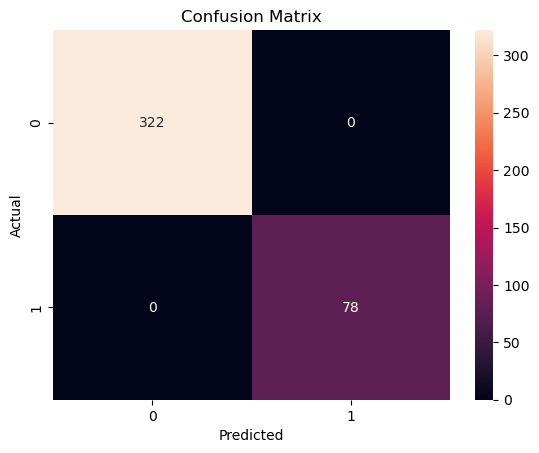

In [20]:
#Cell 20 : Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

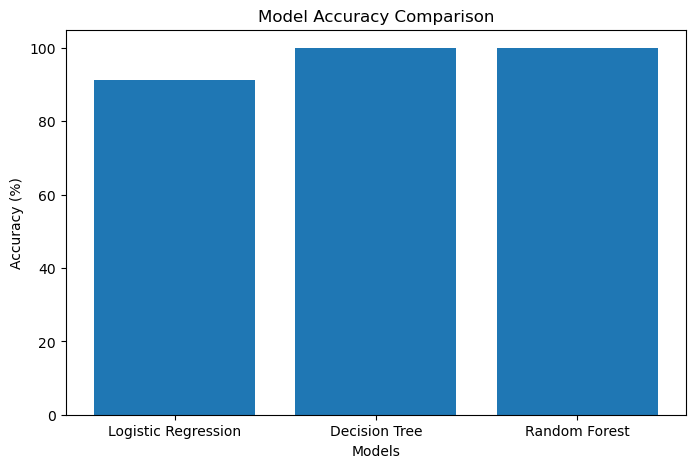

In [21]:
#Cell 21 : Accuracy Comparison
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracy = [lr_acc*100, dt_acc*100, rf_acc*100]
plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.show()